# Polybag Detection — YOLO OBB Training

This notebook trains a **YOLO11 Oriented Bounding Box (OBB)** model to detect polybags in conveyor belt scenes.

**What you need before starting:**
1. The shared Google Drive **folder** link from your team
2. A Google account (for Colab GPU access)

**Steps:**
1. Enable GPU runtime (Runtime → Change runtime type → T4 GPU)
2. Run all cells top to bottom
3. Paste the folder link when prompted

---
**Google Drive folder structure (shared by your team):**
```
📁 shared_folder/
├── 📁 synth_dataset_mcmot/   ← training data
│   ├── images.zip
│   └── labels.zip
├── 📁 synth_dataset_val/     ← validation data
│   ├── images.zip
│   └── labels.zip
└── 📁 synth_dataset_test/    ← test data
    ├── images.zip
    └── labels.zip
```
**7 classes:** pink · blue · yellow · grey · green · red · teal polybag

## 1. Check GPU and Install Dependencies

In [1]:
# Verify that a GPU is available
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode != 0:
    print('⚠️  No GPU detected!')
    print('Go to Runtime → Change runtime type → select T4 GPU, then re-run.')
else:
    print(result.stdout)

Sun Jun 28 11:23:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install the ultralytics library (includes YOLO)
!pip install ultralytics --quiet

import ultralytics
ultralytics.checks()  # prints system info and confirms GPU

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


## 2. Download the Dataset

Paste the **shared Google Drive folder link** below.

The link should look like:  
`https://drive.google.com/drive/folders/XXXXXXXXXXXXXXXX?usp=sharing`

In [3]:
# ── Paste your shared Google Drive folder link here ───────────────────────────
GDRIVE_FOLDER_LINK = 'https://drive.google.com/drive/folders/1oOMvkFBBRVSHDJVLUE4JEVF1u9uvlAI_?usp=sharing'
# ─────────────────────────────────────────────────────────────────────────────

import re

match = re.search(r'/folders/([a-zA-Z0-9_-]+)', GDRIVE_FOLDER_LINK)
if not match:
    raise ValueError('Could not parse the Google Drive folder link. Make sure you copied the full URL.')
folder_id = match.group(1)
print(f'Folder ID: {folder_id}')

!pip install gdown --quiet

# Download the entire folder structure (images.zip + labels.zip for all 3 splits)
!gdown --folder {folder_id} -O /content/ --quiet
print('Download complete.')

Folder ID: 1oOMvkFBBRVSHDJVLUE4JEVF1u9uvlAI_
Download complete.


In [4]:
import zipfile
from pathlib import Path

SPLITS = {
    'synth_dataset_mcmot': 'train',
    'synth_dataset_val':   'val',
    'synth_dataset_test':  'test',
}

# Extract images.zip and labels.zip inside each subfolder
for folder_name in SPLITS:
    folder = Path('/content/AMS_dataset') / folder_name
    for zip_name in ['images.zip', 'labels.zip']:
        zip_path = folder / zip_name
        if zip_path.exists():
            print(f'Extracting {folder_name}/{zip_name} ...')
            with zipfile.ZipFile(zip_path, 'r') as zf:
                zf.extractall(folder)
        else:
            print(f'⚠️  Not found: {zip_path}')

# Verify
print('\n--- Verification ---')
for folder_name, split in SPLITS.items():
    img_dir = Path('/content/AMS_dataset') / folder_name / 'images'
    lbl_dir = Path('/conten/AMS_datasett') / folder_name / 'labels'
    n_img = len(list(img_dir.glob('*.png'))) if img_dir.exists() else 0
    n_lbl = len(list(lbl_dir.glob('*.txt'))) if lbl_dir.exists() else 0
    status = '✅' if n_img > 0 else '❌'
    print(f'{status}  {split:5s} ({folder_name})  —  {n_img} images  |  {n_lbl} labels')

Extracting synth_dataset_mcmot/images.zip ...
Extracting synth_dataset_mcmot/labels.zip ...
Extracting synth_dataset_val/images.zip ...
Extracting synth_dataset_val/labels.zip ...
Extracting synth_dataset_test/images.zip ...
Extracting synth_dataset_test/labels.zip ...

--- Verification ---
✅  train (synth_dataset_mcmot)  —  2000 images  |  0 labels
✅  val   (synth_dataset_val)  —  1004 images  |  0 labels
✅  test  (synth_dataset_test)  —  1004 images  |  0 labels


## 3. Set Up Dataset Configuration

We tell YOLO where the images and labels are, and what the class names are.

In [5]:
import yaml
from pathlib import Path

DATA_ROOT    = Path('/content/AMS_dataset')
TRAIN_IMAGES = DATA_ROOT / 'synth_dataset_mcmot' / 'images'
VAL_IMAGES   = DATA_ROOT / 'synth_dataset_val'   / 'images'
TEST_IMAGES  = DATA_ROOT / 'synth_dataset_test'  / 'images'

In [6]:
# Write the data.yaml configuration file
# YOLO finds labels automatically by replacing 'images' with 'labels' in the path
data_config = {
    'path':  str(DATA_ROOT),
    'train': 'synth_dataset_mcmot/images',
    'val':   'synth_dataset_val/images',
    'test':  'synth_dataset_test/images',
    'nc':    7,
    'names': [
        'pink_polybag', 'blue_polybag', 'yellow_polybag',
        'grey_polybag', 'green_polybag', 'red_polybag', 'teal_polybag'
    ]
}

yaml_path = DATA_ROOT / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print('data.yaml written:')
print(yaml_path.read_text())

data.yaml written:
names:
- pink_polybag
- blue_polybag
- yellow_polybag
- grey_polybag
- green_polybag
- red_polybag
- teal_polybag
nc: 7
path: /content/AMS_dataset
test: synth_dataset_test/images
train: synth_dataset_mcmot/images
val: synth_dataset_val/images



## 4. Preview Some Training Images

A quick sanity check — let's look at a few images with their ground truth labels overlaid.

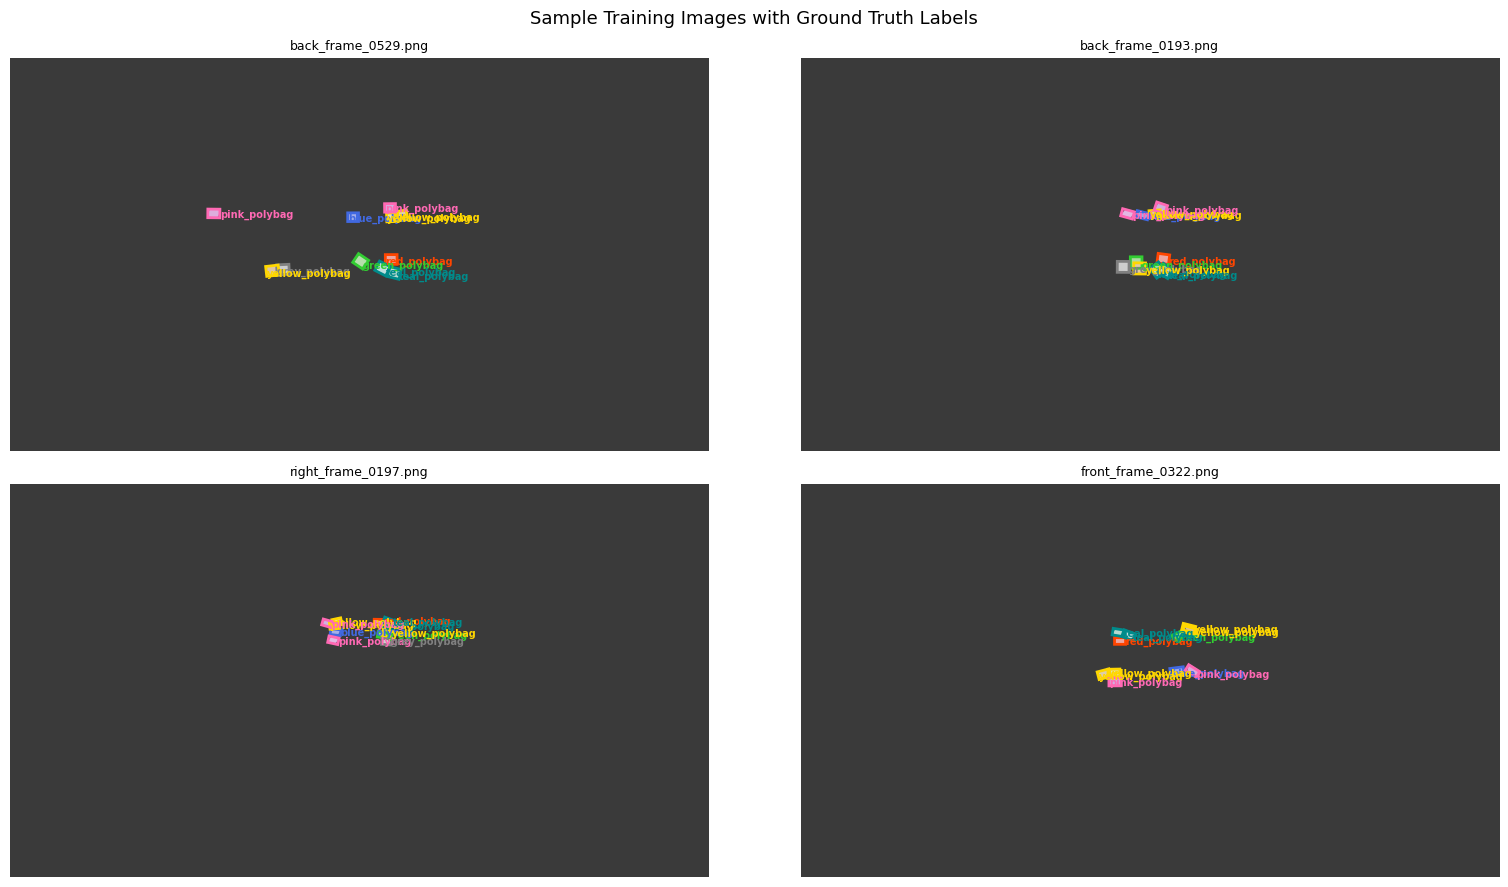

In [7]:
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

CLASS_COLORS = [
    '#FF69B4',  # pink
    '#4169E1',  # blue
    '#FFD700',  # yellow
    '#808080',  # grey
    '#32CD32',  # green
    '#FF4500',  # red
    '#008B8B',  # teal
]
CLASS_NAMES = data_config['names']

sample_images = random.sample(sorted(TRAIN_IMAGES.glob('*.png')), 4)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for ax, img_path in zip(axes.flat, sample_images):
    img = np.array(Image.open(img_path))
    # YOLO convention: labels/ sits next to images/ in the same parent folder
    label_path = TRAIN_IMAGES.parent / 'labels' / (img_path.stem + '.txt')
    h, w = img.shape[:2]

    ax.imshow(img)
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            parts = list(map(float, line.split()))
            cls = int(parts[0])
            pts = np.array(parts[1:]).reshape(4, 2) * [w, h]
            poly = plt.Polygon(pts, fill=False,
                               edgecolor=CLASS_COLORS[cls], linewidth=2)
            ax.add_patch(poly)
            ax.text(pts[0, 0], pts[0, 1], CLASS_NAMES[cls],
                    color=CLASS_COLORS[cls], fontsize=7, fontweight='bold')

    ax.set_title(img_path.name, fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Training Images with Ground Truth Labels', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Train the Model

We use **YOLO11n-OBB** (nano = smallest and fastest) as the starting point.  
Training takes roughly **30–60 minutes** on a Colab T4 GPU for 50 epochs.

| Parameter | Value | Meaning |
|---|---|---|
| `epochs` | 50 | How many times the model sees the full dataset |
| `imgsz` | 1280 | Image size during training (pixels) |
| `batch` | 8 | Images processed at once (limited by GPU memory) |
| `patience` | 20 | Stop early if no improvement for 20 epochs |

In [8]:
from ultralytics import YOLO

model = YOLO('yolo11n-obb.pt')  # downloads automatically if not present

results = model.train(
    data    = str(yaml_path),
    epochs  = 50,
    imgsz   = 1280,
    batch   = 8,
    patience= 20,       # early stopping
    name    = 'polybag_obb',
    project = '/content/runs',
    exist_ok= True,
)

print('\nTraining complete!')
print(f'Best weights saved to: {results.save_dir}/weights/best.pt')

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/AMS_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=polybag_obb, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

## 6. Visualise Training Results

YOLO automatically saves loss curves, precision/recall graphs, and a confusion matrix.

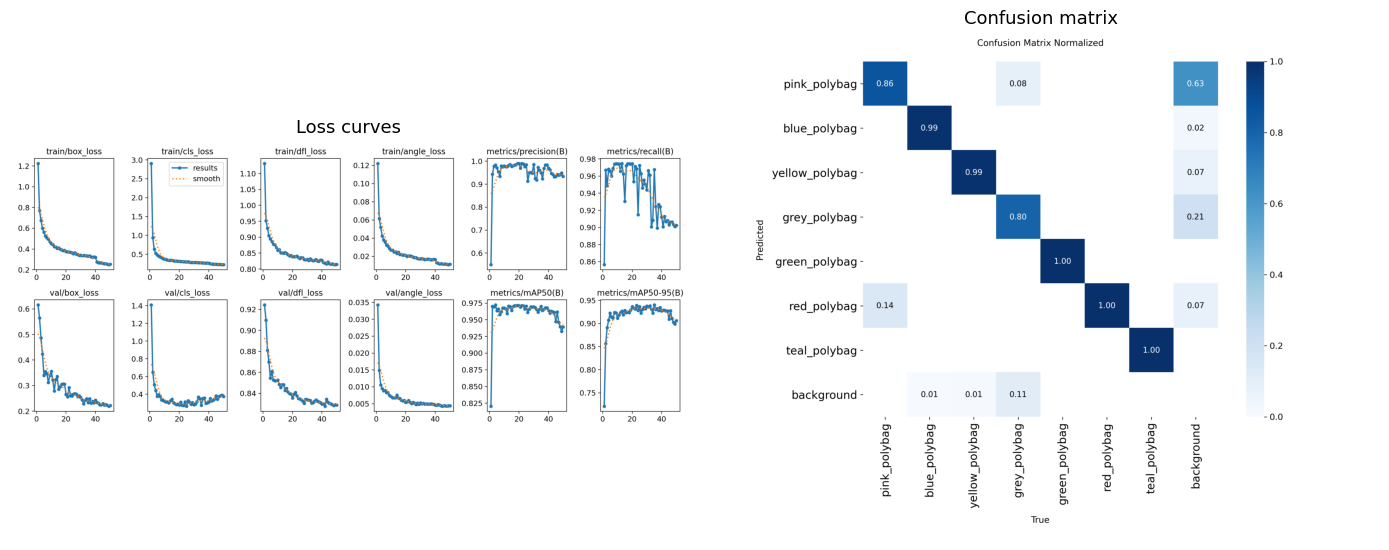

In [9]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

run_dir = Path(results.save_dir)

# Show training curves and confusion matrix side by side
plots = {
    'Loss curves':        run_dir / 'results.png',
    'Confusion matrix':   run_dir / 'confusion_matrix_normalized.png',
    'Precision-Recall':   run_dir / 'PR_curve.png',
    'F1 curve':           run_dir / 'F1_curve.png',
}

available = {k: v for k, v in plots.items() if v.exists()}
fig, axes = plt.subplots(1, len(available), figsize=(7 * len(available), 6))
if len(available) == 1:
    axes = [axes]

for ax, (title, path) in zip(axes, available.items()):
    ax.imshow(Image.open(path))
    ax.set_title(title, fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 7. Run Inference on Test Images

Let's see how the trained model performs on images it has never seen.

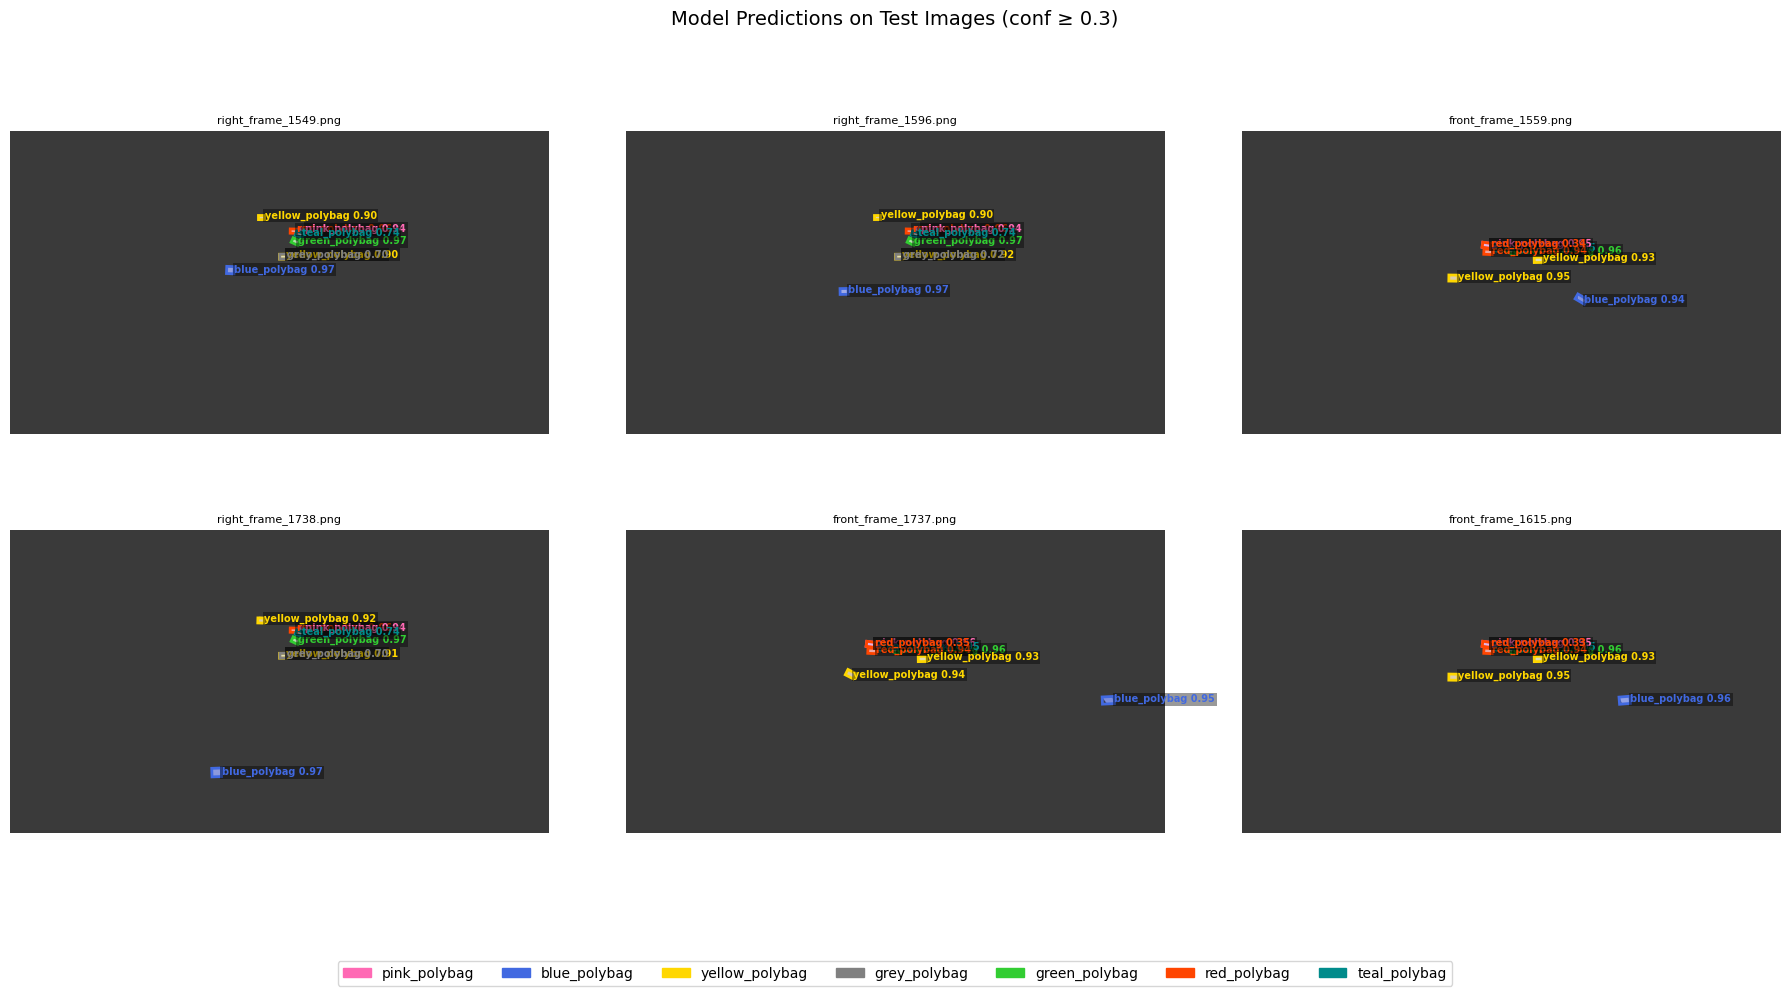

In [10]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from ultralytics import YOLO

# Load the best weights from training
best_model = YOLO(str(run_dir / 'weights' / 'best.pt'))

# Pick 6 random test images
test_imgs = random.sample(sorted(TEST_IMAGES.glob('*.png')), 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, img_path in zip(axes.flat, test_imgs):
    preds = best_model.predict(str(img_path), conf=0.3, verbose=False)[0]
    img = np.array(Image.open(img_path))

    ax.imshow(img)

    if preds.obb is not None and len(preds.obb) > 0:
        corners = preds.obb.xyxyxyxy.cpu().numpy()  # (N, 4, 2)
        confs   = preds.obb.conf.cpu().numpy()
        classes = preds.obb.cls.cpu().numpy().astype(int)

        for pts, conf, cls in zip(corners, confs, classes):
            color = CLASS_COLORS[cls]
            poly  = plt.Polygon(pts, fill=False, edgecolor=color, linewidth=2)
            ax.add_patch(poly)
            label = f'{CLASS_NAMES[cls]} {conf:.2f}'
            ax.text(pts[0, 0], pts[0, 1] - 5, label,
                    color=color, fontsize=7, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.4, pad=1, edgecolor='none'))
    else:
        ax.set_xlabel('No detections', color='red')

    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')

# Legend
patches = [mpatches.Patch(color=c, label=n)
           for c, n in zip(CLASS_COLORS, CLASS_NAMES)]
fig.legend(handles=patches, loc='lower center', ncol=7,
           fontsize=10, framealpha=0.8)

plt.suptitle('Model Predictions on Test Images (conf ≥ 0.3)', fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## 8. Evaluate on the Full Test Set

This gives official metrics: mAP50 and mAP50-95.

In [11]:
metrics = best_model.val(
    data   = str(yaml_path),
    split  = 'test',
    imgsz  = 1280,
    batch  = 8,
    verbose= True,
)

print(f'\nmAP50:    {metrics.box.map50:.4f}')
print(f'mAP50-95: {metrics.box.map:.4f}')

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 140.6±78.7 MB/s, size: 1130.2 KB)
val: Scanning /content/AMS_dataset/synth_dataset_test/labels... 1004 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1004/1004 139.6it/s 7.2s
val: New cache created: /content/AMS_dataset/synth_dataset_test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 126/126 2.1it/s 58.8s
                   all       1004       7028      0.848      0.854      0.849      0.825
          pink_polybag       1004       1004      0.978          1      0.995      0.967
          blue_polybag        942        942      0.978      0.978      0.973      0.894
        yellow_polybag       1004       1994       0.98      0.999      0.993      0.939
          grey_polybag         76         76          0          0          0          0
         green_polybag       1004  

## 9. Download the Trained Weights

Save the best model weights to your Google Drive or download them directly.

In [12]:
# Option A — download directly to your computer
from google.colab import files
files.download(str(run_dir / 'weights' / 'best.pt'))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
# Option B — copy to your Google Drive
from google.colab import drive
drive.mount('/gdrive', force_remount=False)

import shutil
dest = '/gdrive/MyDrive/polybag_best.pt'
shutil.copy(str(run_dir / 'weights' / 'best.pt'), dest)
print(f'Saved to {dest}')

Mounted at /gdrive
Saved to /gdrive/MyDrive/polybag_best.pt
